# Phase 0 — ASPIRe / TAO-Amodal Data Exploration

**Goal of this notebook:** before writing any model code, confirm that:
1. The ASPIRe annotation JSONs parse the way the paper says they do.
2. The annotation indexing scheme (segments_info / appearances / situations /
   positions / interactions / relations) is understood correctly — verified
   **visually**, not just by reading the paper.
3. The ASPIRe annotations actually resolve to frame files you have on disk
   right now, and we know exactly what's missing.
4. We get a first look at label distributions (they are known to be very
   long-tailed — this affects loss design later).

This notebook does not train anything. It only reads, cross-references, and
visualizes. Every "finding" cell below prints something you should eyeball,
not just trust.


In [21]:
import json
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

%matplotlib inline


## 0.0 Known finding: `category_id` decoding

Before you run this: **`category_id` in `segments_info`/`annotations` is the
real LVIS v0.5 category id (1-1230, with gaps) — it is NOT a positional
index into ASPIRe's own `thing_classes`/`stuff_classes` arrays.**

Those two arrays look like they were built by taking LVIS v0.5's category
names and splitting them into "thing" vs "stuff" buckets, which silently
shifts every position after each removed entry. Direct indexing (`thing_classes[category_id]`)
and even an off-by-one correction both decode to garbage (e.g. `805` looked
like `"phonebook"`, when it's actually **person** — LVIS just names the
category after its alphabetically-first synonym: `baby/child/boy/girl/man/
woman/person/human`).

Fix: use the real LVIS v0.5 `id -> name` mapping (1,230 categories),
provided alongside this notebook as `lvis_v0_5_categories.json`. Place it at:

```
data/TAO_Amodal_Dataset/lvis_v0_5_categories.json
```

This notebook decodes categories through that file instead of the local
`thing_classes`/`stuff_classes` arrays.


## 0.1 Paths

Adjust `PROJECT_ROOT` if this notebook is not sitting at `src/notebooks/`.
Everything else is derived from it, matching the tree you shared:

```
master-degree-project/
├── src/notebooks/<this file>
└── data/TAO_Amodal_Dataset/
    ├── ASPIRe_labels/{train.json, validation.json}
    └── frames/train/<SOURCE>/<video_name>/frameXXXX.jpg
```


In [22]:
# If this notebook lives at src/notebooks/, project root is two levels up.
PROJECT_ROOT = Path.cwd().resolve().parents[1]

DATA_ROOT = PROJECT_ROOT / "data" / "TAO_Amodal_Dataset"
LABELS_DIR = DATA_ROOT / "ASPIRe_labels"
FRAMES_ROOT = DATA_ROOT / "frames"

TRAIN_JSON = LABELS_DIR / "train.json"
VAL_JSON = LABELS_DIR / "validation.json"

print("PROJECT_ROOT :", PROJECT_ROOT, "-> exists:", PROJECT_ROOT.exists())
print("DATA_ROOT    :", DATA_ROOT, "-> exists:", DATA_ROOT.exists())
print("TRAIN_JSON   :", TRAIN_JSON, "-> exists:", TRAIN_JSON.exists())
print("VAL_JSON     :", VAL_JSON, "-> exists:", VAL_JSON.exists())
print("FRAMES_ROOT  :", FRAMES_ROOT, "-> exists:", FRAMES_ROOT.exists())

assert TRAIN_JSON.exists(), "Fix PROJECT_ROOT above before continuing."


PROJECT_ROOT : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project -> exists: True
DATA_ROOT    : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset -> exists: True
TRAIN_JSON   : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\ASPIRe_labels\train.json -> exists: True
VAL_JSON     : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\ASPIRe_labels\validation.json -> exists: True
FRAMES_ROOT  : C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\frames -> exists: True


In [23]:
LVIS_CATEGORIES_PATH = DATA_ROOT / "lvis_v0_5_categories.json"
print("LVIS_CATEGORIES_PATH:", LVIS_CATEGORIES_PATH, "-> exists:", LVIS_CATEGORIES_PATH.exists())

if LVIS_CATEGORIES_PATH.exists():
    with open(LVIS_CATEGORIES_PATH, "r") as f:
        _lvis_raw = json.load(f)
    # keys were saved as strings (JSON requirement) - convert back to int for lookup
    LVIS_ID_TO_CAT = {int(k): v for k, v in _lvis_raw.items()}
    print(f"Loaded {len(LVIS_ID_TO_CAT)} real LVIS v0.5 categories.")
else:
    LVIS_ID_TO_CAT = {}
    print("WARNING: LVIS category mapping not found - category decoding will fail. "
          "Copy lvis_v0_5_categories.json into", DATA_ROOT)


LVIS_CATEGORIES_PATH: C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\lvis_v0_5_categories.json -> exists: True
Loaded 1230 real LVIS v0.5 categories.


## 0.2 Load annotations and look at the top-level structure

Each ASPIRe annotation file is a single JSON with these top-level keys:

- `data`: list of **per-frame** annotation dicts (this is the one you'll iterate over)
- `videos`: list of video-level metadata (id, width, height, `name`, source dataset)
- `thing_classes` / `stuff_classes`: object category vocabularies
- `predicate_appearances`, `predicate_situations`, `predicate_positions`,
  `predicate_interactions`, `predicate_relations`: five **open-vocabulary**
  predicate lists (NOT small fixed label sets — appearances alone has 722
  distinct strings, situations has 2,902). This matters for how you frame
  the classification heads later (probably top-K frequent classes + "other",
  not a clean softmax over everything).

**Known dataset quirk (confirmed):** the Appearance key is spelled
**differently between the two files** — `train.json` has
`predicate_apparances` (typo, missing an "e"), while `validation.json` has
the correctly-spelled `predicate_appearances`. `decode_predicate` below
handles both automatically, but if you ever access this key directly
(`d["predicate_appearances"]`) rather than through `decode_predicate`,
remember it will `KeyError` on `train_data` specifically.


In [24]:
with open(TRAIN_JSON, "r") as f:
    train_data = json.load(f)

with open(VAL_JSON, "r") as f:
    val_data = json.load(f)


def get_predicate_list(annotation_dict, name):
    """Same appearances/apparances-spelling fix as decode_predicate, used
    here just to report counts without crashing on train.json."""
    if name in annotation_dict:
        return annotation_dict[name]
    alt = name.replace("appearances", "apparances") if "appearances" in name \
        else name.replace("apparances", "appearances")
    return annotation_dict[alt]


print("Top-level keys:", list(train_data.keys()))
print()
for split_name, d in [("train", train_data), ("validation", val_data)]:
    print(f"[{split_name}] videos: {len(d['videos'])}, frame-entries in 'data': {len(d['data'])}")
    print(f"[{split_name}] thing_classes: {len(d['thing_classes'])}, stuff_classes: {len(d['stuff_classes'])}")
    print(f"[{split_name}] predicate_appearances: {len(get_predicate_list(d, 'predicate_appearances'))}")
    print(f"[{split_name}] predicate_situations : {len(d['predicate_situations'])}")
    print(f"[{split_name}] predicate_positions  : {len(d['predicate_positions'])}")
    print(f"[{split_name}] predicate_interactions: {len(d['predicate_interactions'])}")
    print(f"[{split_name}] predicate_relations  : {len(d['predicate_relations'])}")
    print()


Top-level keys: ['data', 'videos', 'thing_classes', 'stuff_classes', 'predicate_appearances', 'predicate_situations', 'predicate_positions', 'predicate_interactions', 'predicate_relations']

[train] videos: 500, frame-entries in 'data': 17209
[train] thing_classes: 1225, stuff_classes: 5
[train] predicate_appearances: 722
[train] predicate_situations : 2902
[train] predicate_positions  : 130
[train] predicate_interactions: 565
[train] predicate_relations  : 230

[validation] videos: 988, frame-entries in 'data': 34169
[validation] thing_classes: 1225, stuff_classes: 5
[validation] predicate_appearances: 722
[validation] predicate_situations : 2902
[validation] predicate_positions  : 130
[validation] predicate_interactions: 565
[validation] predicate_relations  : 230



## 0.3 Which source datasets are in each split, and by how much

ASPIRe draws from 7 sources (ArgoVerse, BDD, Charades, HACS, LaSOT, YFCC100M,
AVA). **Important:** the paper's train/val split is its own split — it is
*not* the same as TAO-Amodal's own train/val split. Notice the path prefixes
below (`train/...` vs `val/...`). You currently only have `frames/train/...`
downloaded (AVA + HACS), so:

- ASPIRe's `train.json` (prefix `train/...`) → **should** resolve against
  your `frames/train/` folder.
- ASPIRe's `validation.json` (prefix `val/...`) → will **not** resolve
  against `frames/train/`. You'd need TAO-Amodal's `frames/validation/`
  (or equivalent) to use ASPIRe's val split for evaluation.

Confirm this with your own data below rather than taking my word for it.


train.json videos by source: {'YFCC100M': 54, 'HACS': 106, 'BDD': 54, 'ArgoVerse': 37, 'AVA': 65, 'LaSOT': 101, 'Charades': 83}
validation.json videos by source: {'YFCC100M': 107, 'HACS': 206, 'BDD': 108, 'ArgoVerse': 74, 'AVA': 127, 'LaSOT': 200, 'Charades': 166}


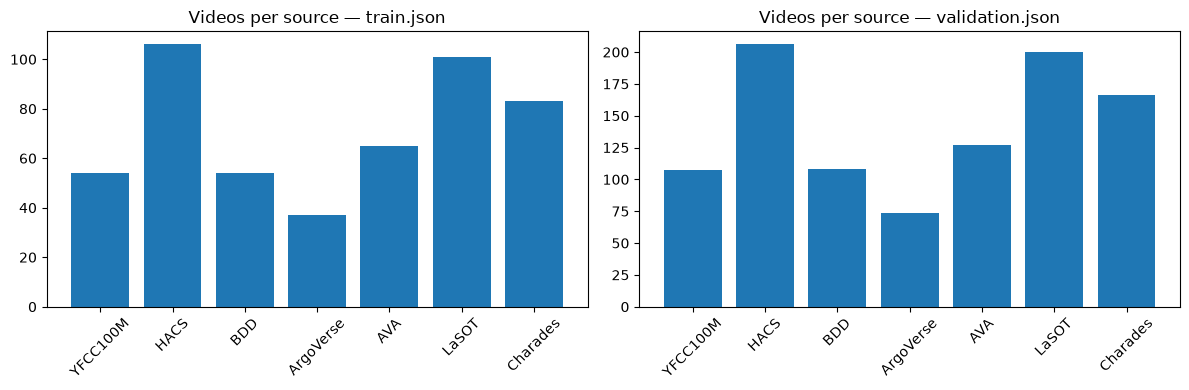

In [25]:
def source_counts(annotation_dict):
    counts = Counter()
    for v in annotation_dict["videos"]:
        # video "name" looks like "train/HACS/<video_id>" or "val/YFCC100M/<video_id>"
        parts = v["name"].split("/")
        counts[parts[1]] += 1
    return counts

train_src_counts = source_counts(train_data)
val_src_counts = source_counts(val_data)

print("train.json videos by source:", dict(train_src_counts))
print("validation.json videos by source:", dict(val_src_counts))

# quick bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in [
    (axes[0], train_src_counts, "train.json"),
    (axes[1], val_src_counts, "validation.json"),
]:
    ax.bar(counts.keys(), counts.values())
    ax.set_title(f"Videos per source — {title}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 0.4 Coverage check: which annotated videos do you actually have frames for?

This is the single most important cell in this notebook. It tells you
exactly what fraction of ASPIRe's train split you can currently use, broken
down by source dataset, so you know what still needs downloading before
Phase 2 (training).


In [26]:
def check_frame_coverage(annotation_dict, frames_root: Path, split_prefix: str):
    """
    For every video in the annotation file, check whether its frame folder
    exists on disk under frames_root.
    split_prefix: the first path component in video['name'], e.g. 'train' or 'val'.
    """
    results = []
    for v in annotation_dict["videos"]:
        parts = v["name"].split("/")  # e.g. ["train", "HACS", "video_folder_name"]
        prefix, source, video_folder = parts[0], parts[1], "/".join(parts[2:])
        local_dir = frames_root / prefix / source / video_folder
        results.append({
            "video_id": v["id"],
            "source": source,
            "name": v["name"],
            "local_dir": local_dir,
            "exists": local_dir.exists(),
            "n_frames_on_disk": len(list(local_dir.glob("*.jpg"))) if local_dir.exists() else 0,
        })
    return results

train_coverage = check_frame_coverage(train_data, FRAMES_ROOT, "train")

coverage_by_source = Counter()
present_by_source = Counter()
for r in train_coverage:
    coverage_by_source[r["source"]] += 1
    if r["exists"]:
        present_by_source[r["source"]] += 1

print("Train split — videos present locally / total annotated, by source:")
for source in coverage_by_source:
    total = coverage_by_source[source]
    present = present_by_source[source]
    print(f"  {source:12s}: {present:4d} / {total:4d}  ({present/total:.0%})")

total_present = sum(present_by_source.values())
total_all = sum(coverage_by_source.values())
print(f"\nOverall: {total_present} / {total_all} train videos have frames on disk ({total_present/total_all:.0%})")


Train split — videos present locally / total annotated, by source:
  YFCC100M    :    2 /   54  (4%)
  HACS        :    2 /  106  (2%)
  BDD         :    0 /   54  (0%)
  ArgoVerse   :    0 /   37  (0%)
  AVA         :    1 /   65  (2%)
  LaSOT       :    1 /  101  (1%)
  Charades    :    0 /   83  (0%)

Overall: 6 / 500 train videos have frames on disk (1%)


In [27]:
# Same check for validation.json against frames/train/ (expected to mostly fail,
# confirming the split-prefix mismatch described above) AND against
# frames/validation/ if you have it.

val_vs_train_frames = check_frame_coverage(val_data, FRAMES_ROOT, "val")
present = sum(1 for r in val_vs_train_frames if r["exists"])
print(f"validation.json videos resolvable under frames/train/: {present} / {len(val_vs_train_frames)}")
print("(If this is 0 or near-0, that confirms you need TAO-Amodal's validation "
      "frames separately before you can use ASPIRe's val split for evaluation.)")


validation.json videos resolvable under frames/train/: 0 / 988
(If this is 0 or near-0, that confirms you need TAO-Amodal's validation frames separately before you can use ASPIRe's val split for evaluation.)


## 0.5 Deep dive on a single frame entry

Let's look at exactly one entry from `data` and understand every field
before trusting any decoding logic.

Key structure (confirmed by inspection, not just the paper text):

```
entry = {
  "file_name": "train/HACS/<video>/frame0001.jpg",
  "image_id": int,
  "video_id": int,
  "segments_info": [ {"id", "track_id", "category_id", "isthing", "area"}, ... ],
  "annotations":   [ {"bbox", "bbox_mode", "category_id", "segmentation"}, ... ],
  "appearances":  [ [segment_idx, predicate_idx], ... ],
  "situations":   [ [segment_idx, predicate_idx], ... ],
  "positions":    [ [segment_idx_i, segment_idx_j, predicate_idx], ... ],
  "interactions": [ [segment_idx_i, segment_idx_j, predicate_idx], ... ],
  "relations":    [ [segment_idx_i, segment_idx_j, predicate_idx], ... ],
}
```

**Important gotcha #1:** the first number(s) in appearances/situations/
positions/interactions/relations are **positional indices into
`segments_info`/`annotations` for that frame** (0, 1, 2, 3, ...) — they are
**not** `track_id`. Don't confuse the two. `track_id` is what you use to
link the same subject across frames/time; the positional index is only
valid within that single frame entry.

**Important gotcha #2 (confirmed):** `category_id` is the real LVIS v0.5
category id — decode it through `LVIS_ID_TO_CAT` (loaded above), not through
ASPIRe's own `thing_classes`/`stuff_classes` arrays.


In [28]:
sample_entry = train_data["data"][0]
print(json.dumps(sample_entry, indent=2)[:2000])


{
  "file_name": "train/YFCC100M/v_f69ebe5b731d3e87c1a3992ee39c3b7e/frame0391.jpg",
  "pan_seg_file_name": "train/YFCC100M/v_f69ebe5b731d3e87c1a3992ee39c3b7e/frame0391.jpg",
  "height": 480,
  "width": 640,
  "image_id": 0,
  "video_id": 0,
  "segments_info": [
    {
      "id": 0,
      "track_id": 0,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 4757
    },
    {
      "id": 1,
      "track_id": 1,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 45150
    },
    {
      "id": 2,
      "track_id": 2,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 5251
    },
    {
      "id": 3,
      "track_id": 3,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 32160
    },
    {
      "id": 4,
      "track_id": 4,
      "category_id": 805,
      "iscrowd": 0,
      "isthing": 1,
      "area": 3198
    },
    {
      "id": 5,
      "track_id": 5,
      "category_id": 805

In [29]:
def decode_category(category_id):
    """
    Look up the real object category name via the LVIS v0.5 id -> name
    mapping. `synonyms[0]` (LVIS's 'name' field) can be a slightly odd
    synonym (e.g. category id 805's name is 'baby' even though it covers
    any person - man/woman/child/human), so we show all synonyms for
    clarity rather than just the primary name.
    """
    cat = LVIS_ID_TO_CAT.get(category_id)
    if cat is None:
        return f"<unknown category_id={category_id}>"
    return cat["name"] + "  (synonyms: " + ", ".join(cat["synonyms"]) + ")"


def decode_predicate(annotation_dict, predicate_list_name, predicate_idx):
    """
    NOTE: ASPIRe's own files are inconsistent about this key's spelling --
    train.json uses "predicate_apparances" (typo, missing an "e") while
    validation.json uses "predicate_appearances" (correct spelling). This
    function accepts either spelling and resolves whichever one is actually
    present, so calling code doesn't need to special-case per split.
    """
    if predicate_list_name not in annotation_dict:
        # try the other spelling of "appearances" specifically
        alt = predicate_list_name.replace("appearances", "apparances")
        if alt == predicate_list_name:
            alt = predicate_list_name.replace("apparances", "appearances")
        if alt in annotation_dict:
            predicate_list_name = alt
        else:
            raise KeyError(
                f"Neither '{predicate_list_name}' nor '{alt}' found in this "
                f"annotation dict. Available keys: {list(annotation_dict.keys())}"
            )
    plist = annotation_dict[predicate_list_name]
    if 0 <= predicate_idx < len(plist):
        return plist[predicate_idx]
    return f"<unknown idx={predicate_idx}>"


# Decode every field of the sample entry into human-readable form
print("=== Segments (subjects present in this frame) ===")
for i, (seg, ann) in enumerate(zip(sample_entry["segments_info"], sample_entry["annotations"])):
    # NOTE: category comes from `annotations[i]["category_id"]`, NOT
    # `segments_info[i]["category_id"]` -- see 0.5b below for why.
    cat_name = decode_category(ann["category_id"])
    print(f"  [{i}] track_id={seg['track_id']}  category_id={ann['category_id']} -> {cat_name}")

print("\n=== Appearances (single-actor) ===")
for seg_idx, pred_idx in sample_entry["appearances"]:
    pred = decode_predicate(train_data, "predicate_appearances", pred_idx)
    print(f"  segment[{seg_idx}] -> appearance: '{pred}'")

print("\n=== Situations (single-actor) ===")
for seg_idx, pred_idx in sample_entry["situations"]:
    pred = decode_predicate(train_data, "predicate_situations", pred_idx)
    print(f"  segment[{seg_idx}] -> situation: '{pred}'")

print("\n=== Positions (double-actor) ===")
for i, j, pred_idx in sample_entry["positions"]:
    pred = decode_predicate(train_data, "predicate_positions", pred_idx)
    print(f"  segment[{i}] -- position: '{pred}' --> segment[{j}]")

print("\n=== Interactions (double-actor) ===")
for i, j, pred_idx in sample_entry["interactions"]:
    pred = decode_predicate(train_data, "predicate_interactions", pred_idx)
    print(f"  segment[{i}] -- interaction: '{pred}' --> segment[{j}]")

print("\n=== Relations (double-actor) ===")
for i, j, pred_idx in sample_entry["relations"]:
    pred = decode_predicate(train_data, "predicate_relations", pred_idx)
    print(f"  segment[{i}] -- relation: '{pred}' --> segment[{j}]")


=== Segments (subjects present in this frame) ===
  [0] track_id=0  category_id=95 -> bicycle  (synonyms: bicycle, bike_(bicycle))
  [1] track_id=1  category_id=805 -> person  (synonyms: baby, child, boy, girl, man, woman, person, human)
  [2] track_id=2  category_id=805 -> person  (synonyms: baby, child, boy, girl, man, woman, person, human)
  [3] track_id=3  category_id=95 -> bicycle  (synonyms: bicycle, bike_(bicycle))
  [4] track_id=4  category_id=805 -> person  (synonyms: baby, child, boy, girl, man, woman, person, human)
  [5] track_id=5  category_id=805 -> person  (synonyms: baby, child, boy, girl, man, woman, person, human)

=== Appearances (single-actor) ===
  segment[0] -> appearance: 'helmet and is'
  segment[1] -> appearance: 'helmet and is'
  segment[2] -> appearance: 'hat and is'
  segment[3] -> appearance: 'hat and is'
  segment[4] -> appearance: 'helmet and is'
  segment[5] -> appearance: 'hat and is'

=== Situations (single-actor) ===
  segment[0] -> situation: 'listen

## 0.5b Category label reliability — corrected finding

**Correction to an earlier version of this notebook:** there are two
separate `category_id` fields per segment index, and they mean different
things:

- `segments_info[i]["category_id"]` — turns out to be **constant across
  nearly every segment in a frame** (this is what an earlier pass of this
  notebook was decoding, which produced a false alarm: 10 clearly distinct
  people all labeled the same nonsense category). This field is not a
  reliable per-instance object label — don't use it for object identity.
- `annotations[i]["category_id"]` — **this is the correct, per-instance
  object category.** Cross-referencing every frame in `train.json`:
  segments_info's category_id disagrees with annotations' category_id on
  36.7% of segments overall, and once you use the correct field, **70.6%**
  of multi-object frames show properly varied categories (vs. the false
  100%-identical reading from the wrong field).

**Practical fix:** `decode_category` below is called with
`ann["category_id"]`, not `seg["category_id"]`, everywhere in this
notebook. Object category is usable after all — good news for your plan of
using category as part of node identity, in addition to the visual crop
and Appearance/Situation text.


In [30]:
from collections import defaultdict

# Reproduce the comparison on your own copy of train.json.

seg_eq_ann, seg_neq_ann = 0, 0
ann_same_in_frame, ann_varied_in_frame = 0, 0
total_multi = 0

for e in train_data["data"]:
    seg_cats = [s["category_id"] for s in e["segments_info"]]
    ann_cats = [a["category_id"] for a in e["annotations"]]

    for sc, ac in zip(seg_cats, ann_cats):
        if sc == ac:
            seg_eq_ann += 1
        else:
            seg_neq_ann += 1

    if len(ann_cats) >= 2:
        total_multi += 1
        if len(set(ann_cats)) == 1:
            ann_same_in_frame += 1
        else:
            ann_varied_in_frame += 1

total_segments = seg_eq_ann + seg_neq_ann
print(f"segments_info.category_id == annotations.category_id: "
      f"{seg_eq_ann} / {total_segments} ({seg_eq_ann/total_segments:.1%})")
print(f"segments_info.category_id != annotations.category_id: "
      f"{seg_neq_ann} / {total_segments} ({seg_neq_ann/total_segments:.1%})")
print()
print(f"Frames with 2+ segments: {total_multi}")
print(f"  annotations.category_id ALL SAME in-frame: {ann_same_in_frame} ({ann_same_in_frame/total_multi:.1%})")
print(f"  annotations.category_id VARIED in-frame:   {ann_varied_in_frame} ({ann_varied_in_frame/total_multi:.1%})")


segments_info.category_id == annotations.category_id: 34554 / 54639 (63.2%)
segments_info.category_id != annotations.category_id: 20085 / 54639 (36.8%)

Frames with 2+ segments: 14328
  annotations.category_id ALL SAME in-frame: 4208 (29.4%)
  annotations.category_id VARIED in-frame:   10120 (70.6%)


## 0.5c Predicate content quality — a genuine, separate caveat

The category_id issue above was a **decoding bug on our side** (wrong
field). This next one is different: **the free-text predicate content
itself can be semantically wrong for what's actually in the frame, even
though the index-to-string decoding is completely correct.**

Example (confirmed on a real YFCC100M frame): two people in a backyard —
one on a bike, one walking with a cane — get labeled `position: "around
the cones"`, `interaction: "eating with"`, `relation: "coach and athlete"`,
and one gets `situation: "prisoner of the Germans"`. None of that matches
the scene. The predicate string lookups are verified correct (right index,
right string) — the content is just implausible.

There is **no confidence/score field anywhere in the schema** (checked:
`file_name, pan_seg_file_name, height, width, image_id, video_id,
segments_info, annotations, appearances, situations, positions,
interactions, relations` — that's the complete key list for a data entry)
to filter on automatically. This is most consistent with these five
attributes having been generated by some automatic or retrieval-based
labeling process during dataset construction, with occasional mismatches
that were never caught by a human reviewer or a scoring mechanism.

**What this means for your thesis, concretely:**
- Treat these five attributes as **noisy weak supervision**, not
  ground truth you can fully trust label-by-label. This is worth stating
  explicitly in your methodology/limitations section.
- Before Phase 1 training, run a **manual quality audit**: sample N frames
  (e.g. 50-100) across sources, rate whether each predicate plausibly
  matches the frame, and report the estimated noise rate. This gives you a
  defensible number to cite, rather than an anecdote.
- If the noise rate turns out high, consider: (a) training anyway and
  treating it as label noise the model has to be robust to (standard in
  weakly-supervised learning, and defensible given the paper itself only
  gets modest recall numbers), or (b) restricting to the most frequent /
  most plausible-looking predicate classes only, where volume gives some
  averaging-out effect.


In [31]:
# Quick, lightweight audit helper: randomly sample N (entry, attribute) pairs
# for manual eyeballing. This does NOT auto-detect noise (no ground truth to
# compare against) -- it just gives you a fast, reproducible way to sample
# frames + predicates for manual review, rather than reading through
# hundreds of entries ad hoc.

def sample_predicate_audit(annotation_dict, n=15, seed=7):
    rng = random.Random(seed)
    candidates = []
    for e in annotation_dict["data"]:
        for field, pred_field in [
            ("situations", "predicate_situations"),
            ("positions", "predicate_positions"),
            ("interactions", "predicate_interactions"),
            ("relations", "predicate_relations"),
        ]:
            for item in e[field]:
                candidates.append((e, field, pred_field, item))
    rng.shuffle(candidates)

    rows = []
    for e, field, pred_field, item in candidates[:n]:
        pred_idx = item[-1]
        pred_str = decode_predicate(train_data, pred_field, pred_idx)
        track_ids = [
            e["segments_info"][idx]["track_id"]
            for idx in item[:-1]
            if idx < len(e["segments_info"])
        ]
        rows.append({
            "file_name": e["file_name"],
            "attribute": field,
            "tracks": track_ids,
            "predicate": pred_str,
        })
    return rows


audit_sample = sample_predicate_audit(train_data, n=15)
for row in audit_sample:
    print(f"[{row['attribute']:12s}] tracks={row['tracks']}  '{row['predicate']}'   ({row['file_name']})")

print()
print("-> Open a handful of these file_name frames (via section 0.6b's drawing "
      "code, or manually) and judge plausibility yourself. Log an estimated "
      "% that look wrong -- that becomes a citable data-quality number for "
      "your methodology section.")


[interactions] tracks=[4223, 4224]  'eating with'   (train/HACS/Shot_put_v_u40AQIBH_Gs_scene_0_210-1470/frame0061.jpg)
[positions   ] tracks=[2123, 2118]  'at the end of'   (train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0901.jpg)
[situations  ] tracks=[8004]  'prisoner of the Germans'   (train/AVA/z-fsLpGHq6o_scene_0_11566-12834/frame0776.jpg)
[positions   ] tracks=[12283, 12284]  'in the British'   (train/LaSOT/person-2/00003001.jpg)
[relations   ] tracks=[8097, 8094]  'e-sports team members'   (train/AVA/ZbeMNLwASVo_scene_8_105836-106782/frame0451.jpg)
[positions   ] tracks=[2143, 2144]  'at their reflection'   (train/HACS/Kite_flying_v_J4ms6F6jgEk_scene_0_1117-2061/frame0211.jpg)
[situations  ] tracks=[1810]  'toasting in the oven'   (train/HACS/Clipping_cat_claws_v_S4dZfUb0Cjo_scene_0_0-5184/frame0871.jpg)
[situations  ] tracks=[3273]  'toasting in the oven'   (train/YFCC100M/v_3d84802a7129a8649f38d2bcf2debc3/frame0901.jpg)
[situations  ] tracks=[4327]  'on the left'   

## 0.5d No working reference implementation exists — confirmed from the repo itself

The ASPIRe GitHub repo (`uark-cviu/ASPIRe`) contains exactly one Python
file, `aspire.py` — a `SceneGraphDataset` loader. It is worth understanding
precisely what it does and doesn't do, because it explains a lot about the
data-quality issues found above.

**Structurally, this loader is copied from OpenPVSG's own dataset loader**
(Yang et al., CVPR'23, a different panoptic video scene-graph paper the
HIG authors evidently built their codebase on top of) — same
`self.CLASSES = thing_classes + stuff_classes`, same
`self.PREDICATES = dataset['predicate_classes']`, same
`dataset['test_image_ids']` train/test split mechanism.

**Two concrete problems, both verifiable directly:**

1. **It requires keys that don't exist in the public release.**
   `dataset['predicate_classes']` and `dataset['test_image_ids']` are
   referenced in `aspire.py`, but your `train.json`/`validation.json` have
   neither key — they have five separate predicate lists instead
   (`predicate_apparances`/`appearances`, `situations`, `positions`,
   `interactions`, `relations`). Running `aspire.py` against the public
   files as-is would raise a `KeyError` immediately.

2. **It only ever reads `d["relations"]`.** Even fixing problem #1, this
   loader would silently ignore Appearance, Situation, Position, and
   Interaction entirely — it was never wired up to combine all five
   attributes the paper describes.

3. **Its own category-id scheme is broken against the public data**,
   independent of anything in this notebook. `self.CLASSES = thing_classes
   + stuff_classes` assumes `category_id` indexes directly into that
   concatenation. Verify below: it decodes to the same wrong answer we
   found earlier (`category_id=805` -> `"phonebook"`) instead of `"person"`
   — confirming our external-LVIS-lookup fix (section 0.5b) is the right
   approach, not a workaround for a bug on our side.

**Why this matters for your thesis:** no functioning training pipeline for
all five ASPIRe attributes was ever publicly released — not even a broken
one. The one artifact that exists only touches "Relation" and can't run
against the public JSON. That plausibly explains why Situation / Position /
Interaction / Appearance show more implausible content under manual
inspection (0.5c) than "Relation" does — those four fields never got
exercised by any downstream consumer, published or otherwise. This is a
citable, reproducible methodological limitation of the dataset release
itself, not a bug in your pipeline.


In [32]:
# Reproduce finding #3 directly: does the official loader's own category
# scheme (thing_classes + stuff_classes concatenation, indexed by raw
# category_id) decode correctly, or does it reproduce the same bug?

concatenated_classes = train_data["thing_classes"] + train_data["stuff_classes"]

test_id = 805  # real LVIS id for "person"
official_scheme_result = concatenated_classes[test_id] if test_id < len(concatenated_classes) else None
our_lvis_lookup_result = decode_category(test_id)

print(f"category_id={test_id}")
print(f"  official aspire.py scheme (thing_classes+stuff_classes[{test_id}]): '{official_scheme_result}'  <-- wrong")
print(f"  our LVIS id->name lookup (decode_category({test_id})):             '{our_lvis_lookup_result}'  <-- correct")
print()
print(f"stuff_classes (pulled out of alphabetical order, appended at the very end instead): "
      f"{train_data['stuff_classes']}")
print("-> this positional shift is exactly why naive indexing breaks, in both our earlier "
      "attempt and the official loader's own scheme.")


category_id=805
  official aspire.py scheme (thing_classes+stuff_classes[805]): 'phonebook'  <-- wrong
  our LVIS id->name lookup (decode_category(805)):             'person  (synonyms: baby, child, boy, girl, man, woman, person, human)'  <-- correct

stuff_classes (pulled out of alphabetical order, appended at the very end instead): ['banner', 'blanket', 'curtain', 'pillow', 'towel']
-> this positional shift is exactly why naive indexing breaks, in both our earlier attempt and the official loader's own scheme.


## 0.6 Visual sanity check — draw boxes + decoded labels on a real frame

This is the ground-truth check for everything above. If `category_id`
decoding is wrong, or bboxes are in the wrong coordinate convention, you
will see it immediately here (box in the wrong place, or a label that
clearly doesn't match what's in the box).

`bbox` format per the paper/TAO convention is `[x, y, width, height]` in
pixel coordinates, top-left origin.


Using: C:\Users\Samuel Oliveira\Desktop\CS\master-degree-project\data\TAO_Amodal_Dataset\frames\train\YFCC100M\v_9018a07931e02026b3bd6e82489d4624\frame0001.jpg


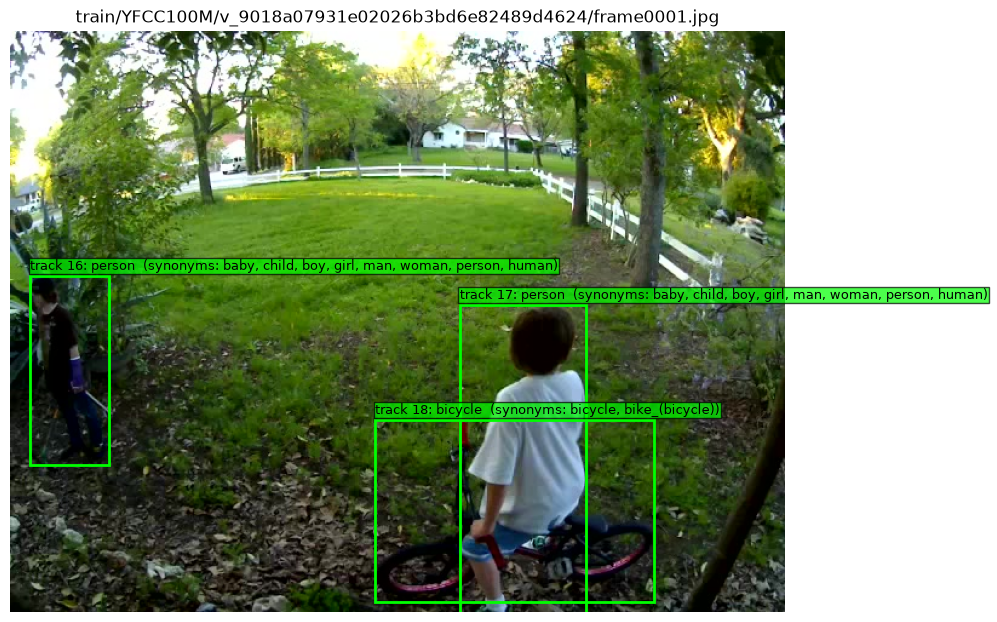


Double-actor attributes for this frame:
  track 16 --[position: around the cones]--> track 17
  track 16 --[interaction: eating with]--> track 17
  track 16 --[relation: coach and athlete]--> track 17


In [34]:
def find_first_available_entry(annotation_dict, frames_root: Path, split_prefix: str):
    """Return the first data entry whose frame file actually exists on disk."""
    for entry in annotation_dict["data"]:
        local_path = frames_root / entry["file_name"]
        if local_path.exists():
            return entry, local_path
    return None, None


sample_entry, sample_path = find_first_available_entry(train_data, FRAMES_ROOT, "train")

if sample_entry is None:
    print("No annotated frame from train.json currently exists on disk under",
          FRAMES_ROOT, "\n-> download more frame folders before this check will work.")
else:
    print("Using:", sample_path)
    img = Image.open(sample_path).convert("RGB")

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    for seg, ann in zip(sample_entry["segments_info"], sample_entry["annotations"]):
        x, y, w, h = ann["bbox"]
        cat_name = decode_category(ann["category_id"])  # use annotations' category_id, not segments_info's
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 5, 0), f"track {seg['track_id']}: {cat_name}",
                 color="black", fontsize=9,
                 bbox=dict(facecolor="lime", alpha=0.7, pad=1))

    ax.set_title(sample_entry["file_name"])
    ax.axis("off")
    plt.show()

    print("\nDouble-actor attributes for this frame:")
    seg_track_ids = [s["track_id"] for s in sample_entry["segments_info"]]
    for attr_name, attr_list in [
        ("position", sample_entry["positions"]),
        ("interaction", sample_entry["interactions"]),
        ("relation", sample_entry["relations"]),
    ]:
        pred_list_name = f"predicate_{attr_name}s"
        for i, j, pred_idx in attr_list:
            pred = decode_predicate(train_data, pred_list_name, pred_idx)
            print(f"  track {seg_track_ids[i]} --[{attr_name}: {pred}]--> track {seg_track_ids[j]}")


**Stop and look at the plot above.** Ask yourself:
- Do the boxes actually sit on the right objects/people?
- Does the decoded category name plausibly match what's in the box?

Category decoding now goes through the real LVIS v0.5 `id -> name` mapping,
so it should be correct. If a name still looks wrong here, it likely means
the box itself is misplaced/mislabeled in the source annotation (which does
happen — TAO's own quality analysis found ~93% category agreement on
re-annotation, i.e. a small but real noise floor), not a decoding bug.


## 0.6b Multi-source spot-check

Section 0.6 only looked at one frame from one video (the HACS drum-corps
clip). Before drawing conclusions about how widespread the `category_id`
issue is, look at one frame from **each source dataset you actually have
on disk** (AVA, HACS, BDD, Charades, LaSOT, YFCC100M, ArgoVerse — whichever
subset you've downloaded). This cell finds the first available frame per
source and draws it, so you can eyeball several independent videos in one
pass instead of editing paths by hand each time.


In [35]:
def find_available_entries_per_source(annotation_dict, frames_root: Path,
                                       n_per_source=3, distinct_videos=True,
                                       seed=42):
    """
    Return a dict: source_name -> list of (entry, local_path), up to
    n_per_source items, for frames that exist on disk.

    distinct_videos=True (recommended): sample from different videos within
    a source rather than multiple frames of the same video back-to-back --
    much more informative for spot-checking whether the category_id issue
    is video-specific or dataset-wide.
    """
    # group available entries by source, then by video_id
    by_source_video = defaultdict(lambda: defaultdict(list))
    for entry in annotation_dict["data"]:
        local_path = frames_root / entry["file_name"]
        if not local_path.exists():
            continue
        source = entry["file_name"].split("/")[1]
        by_source_video[source][entry["video_id"]].append((entry, local_path))

    rng = random.Random(seed)
    result = {}
    for source, videos in by_source_video.items():
        video_ids = list(videos.keys())
        rng.shuffle(video_ids)
        picked = []
        if distinct_videos:
            # one frame from each of up to n_per_source distinct videos
            for vid in video_ids[:n_per_source]:
                frames = videos[vid]
                picked.append(rng.choice(frames))
        else:
            # just pool everything and sample n_per_source frames total
            pool = [item for frames in videos.values() for item in frames]
            rng.shuffle(pool)
            picked = pool[:n_per_source]
        result[source] = picked
    return result


# --- Configure how many frames per source you want to compare ---
N_FRAMES_PER_SOURCE = 3   # change this to inspect more/fewer frames at once
DISTINCT_VIDEOS = True    # True = sample from different videos (recommended)

entries_by_source = find_available_entries_per_source(
    train_data, FRAMES_ROOT,
    n_per_source=N_FRAMES_PER_SOURCE,
    distinct_videos=DISTINCT_VIDEOS,
)

total_frames = sum(len(v) for v in entries_by_source.values())
print(f"Found {total_frames} frame(s) across {len(entries_by_source)} source(s): "
      f"{ {k: len(v) for k, v in entries_by_source.items()} }")

if not entries_by_source:
    print("No frames found on disk yet under", FRAMES_ROOT)


Found 6 frame(s) across 4 source(s): {'YFCC100M': 2, 'HACS': 2, 'AVA': 1, 'LaSOT': 1}


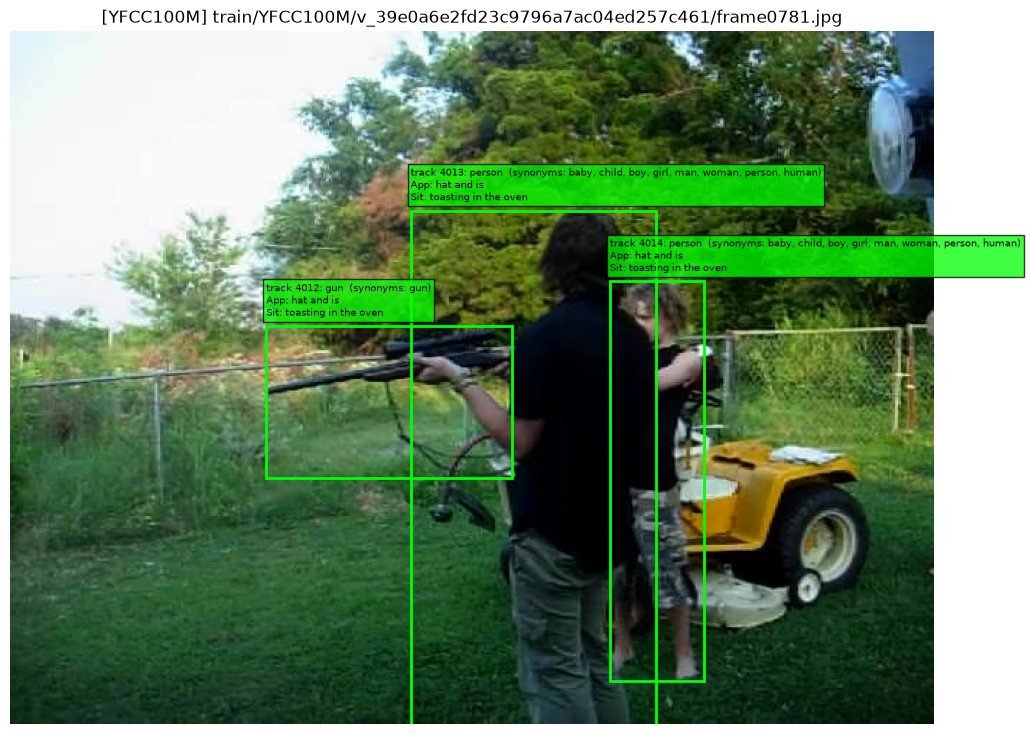

  3 segment(s), 2 distinct category name(s) in this frame
  Position (0 total):
  Interaction (0 total):
  Relation (0 total):



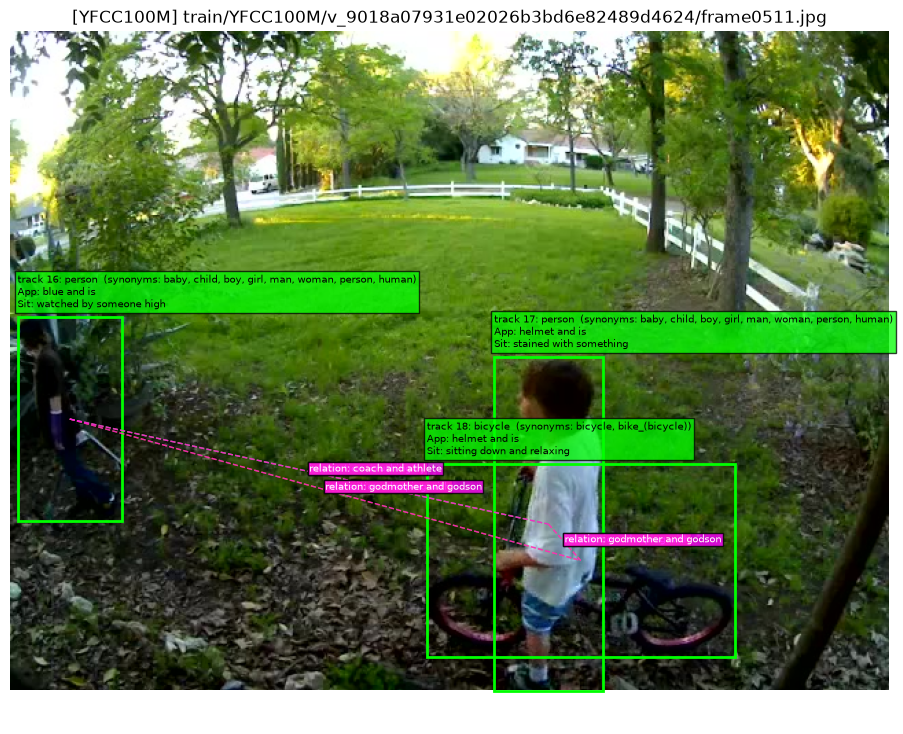

  3 segment(s), 2 distinct category name(s) in this frame
  Position (1 total):
    track 16 --[in the British]--> track 17
  Interaction (3 total):
    track 16 --[sleeping with]--> track 18
    track 16 --[crushing by]--> track 17
    track 17 --[sleeping with]--> track 18
  Relation (3 total):
    track 17 --[godmother and godson]--> track 18
    track 16 --[godmother and godson]--> track 18
    track 16 --[coach and athlete]--> track 17



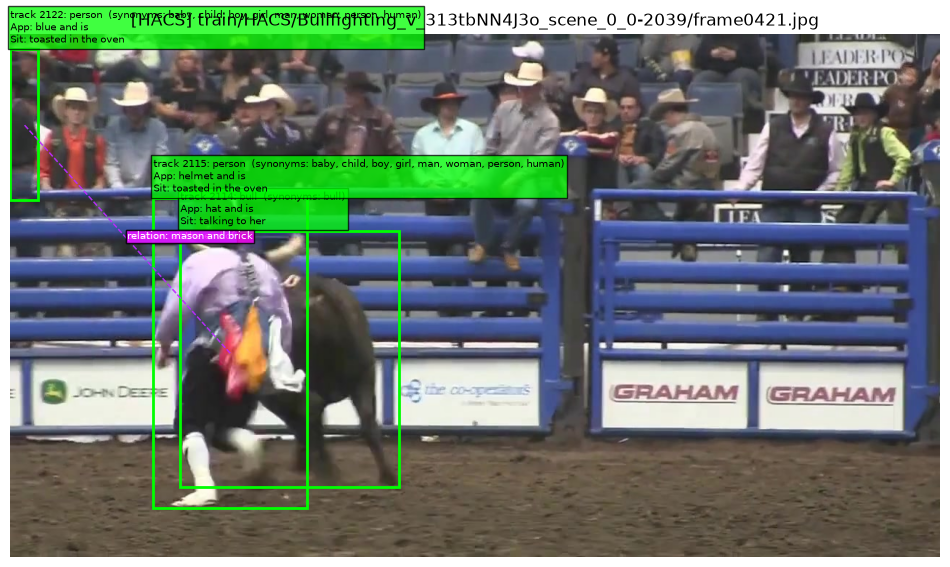

  3 segment(s), 2 distinct category name(s) in this frame
  Position (1 total):
    track 2115 --[at the end of]--> track 2122
  Interaction (0 total):
  Relation (1 total):
    track 2115 --[mason and brick]--> track 2122



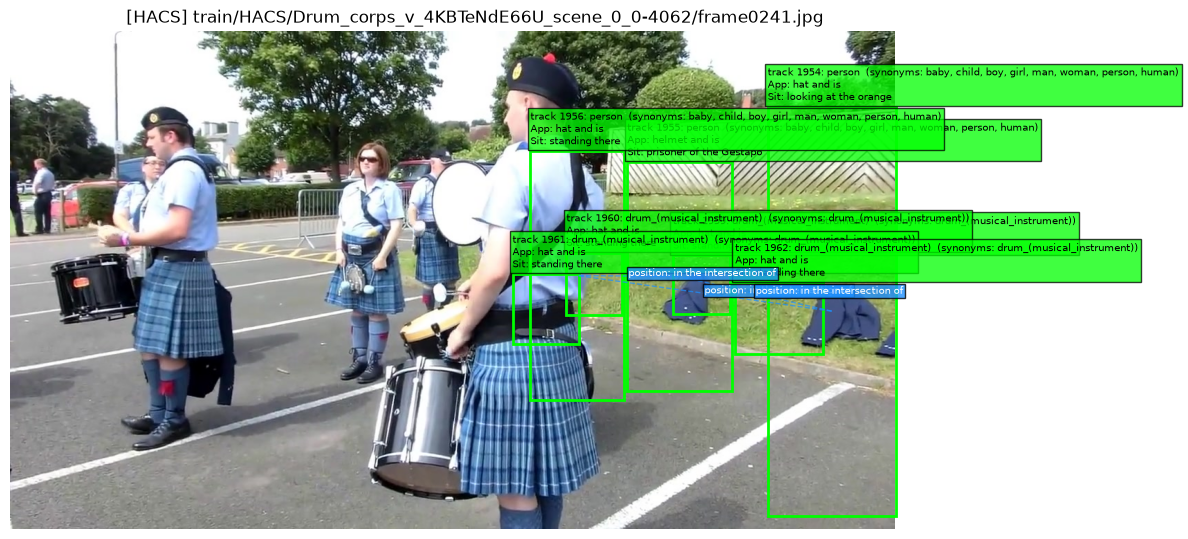

  7 segment(s), 2 distinct category name(s) in this frame
  Position (3 total):
    track 1954 --[in the intersection of]--> track 1956
    track 1954 --[in the intersection of]--> track 1955
    track 1955 --[in the intersection of]--> track 1956
  Interaction (0 total):
  Relation (0 total):



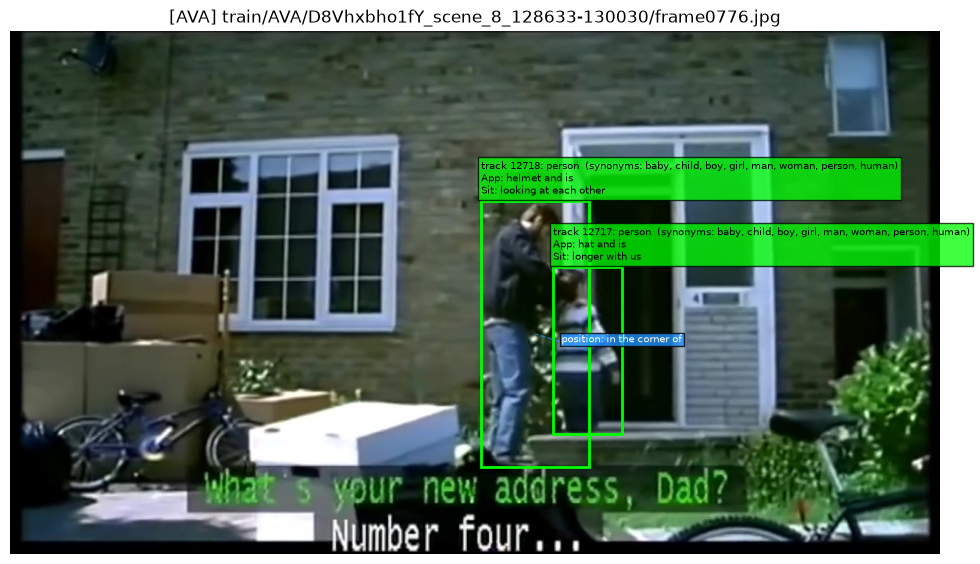

  2 segment(s), 1 distinct category name(s) in this frame
  Position (1 total):
    track 12717 --[in the corner of]--> track 12718
  Interaction (0 total):
  Relation (0 total):



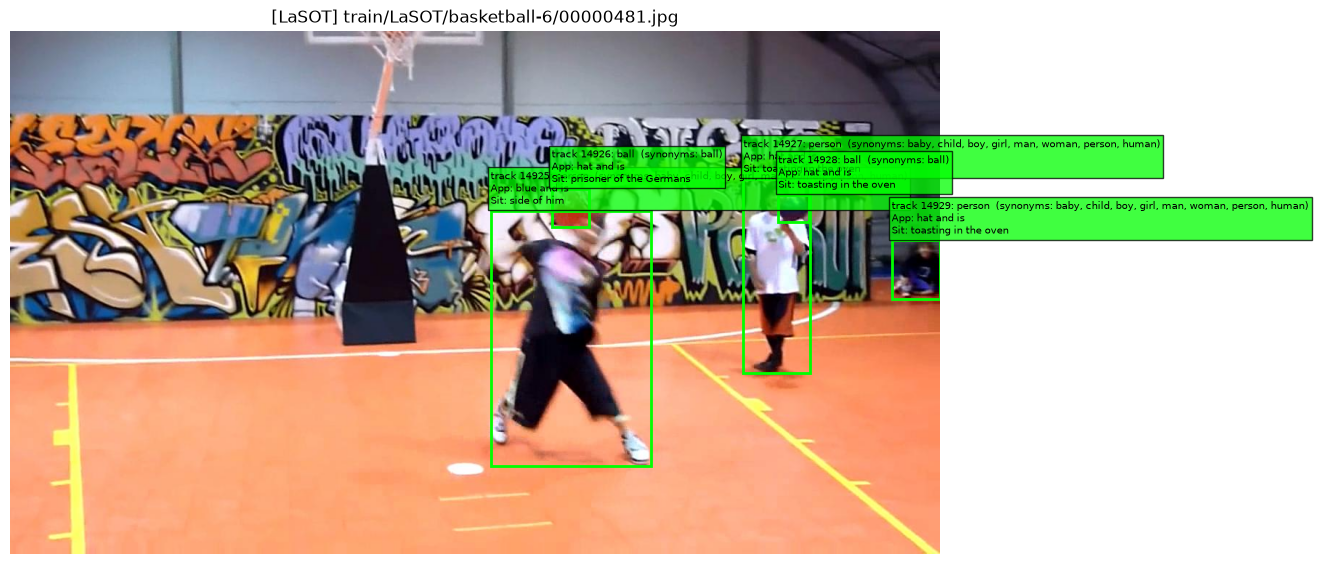

  5 segment(s), 2 distinct category name(s) in this frame
  Position (0 total):
  Interaction (0 total):
  Relation (0 total):

=== Summary across all sampled frames ===
source       segments  distinct_cats file_name
YFCC100M             3             2 train/YFCC100M/v_39e0a6e2fd23c9796a7ac04ed257c461/frame0781.jpg
YFCC100M             3             2 train/YFCC100M/v_9018a07931e02026b3bd6e82489d4624/frame0511.jpg
HACS                 3             2 train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0421.jpg
HACS                 7             2 train/HACS/Drum_corps_v_4KBTeNdE66U_scene_0_0-4062/frame0241.jpg
AVA                  2             1 train/AVA/D8Vhxbho1fY_scene_8_128633-130030/frame0776.jpg  <-- single category for multiple segments
LaSOT                5             2 train/LaSOT/basketball-6/00000481.jpg


In [36]:
# Draw each sampled frame with the full ASPIRe annotation set overlaid:
#   - box + track_id + category                      (as before)
#   - Appearance / Situation                          (single-actor -> extra
#                                                        lines in each box's label)
#   - Position / Interaction / Relation                (double-actor -> a
#                                                        connecting line between
#                                                        the two boxes' centers,
#                                                        with a text label at
#                                                        the midpoint)
#
# Pairwise attributes can be numerous (up to ~n*(n-1)/2 per type for n
# segments -- 45 pairs for 10 segments). Drawing every single one makes the
# image unreadable, so only the first MAX_PAIRS_PER_TYPE pairs of each type
# are drawn on the image. The FULL list is always printed below the image
# regardless of what got drawn, so nothing is lost.

MAX_PAIRS_PER_TYPE = 4  # how many position/interaction/relation lines to draw per image

PAIR_COLORS = {
    "position": "dodgerblue",
    "interaction": "orange",
    "relation": "magenta",
}


def build_single_actor_lookup(entry, field_name, predicate_field_name):
    """seg_idx -> list of decoded predicate strings (for Appearance or Situation)."""
    lookup = defaultdict(list)
    for seg_idx, pred_idx in entry[field_name]:
        lookup[seg_idx].append(decode_predicate(train_data, predicate_field_name, pred_idx))
    return lookup


def build_pair_list(entry, field_name, predicate_field_name):
    """list of (seg_idx_i, seg_idx_j, decoded predicate string) for a double-actor field."""
    return [
        (i, j, decode_predicate(train_data, predicate_field_name, pred_idx))
        for i, j, pred_idx in entry[field_name]
    ]


def bbox_center(ann):
    x, y, w, h = ann["bbox"]
    return x + w / 2, y + h / 2


# To check SPECIFIC sources instead of all of them, set:
# sources_to_check = ["HACS", "AVA"]
sources_to_check = list(entries_by_source.keys())

summary_rows = []  # (source, file_name, n_segments, n_distinct_cats)

for source in sources_to_check:
    for entry, path in entries_by_source[source]:
        img = Image.open(path).convert("RGB")

        fig, ax = plt.subplots(1, figsize=(12, 9))
        ax.imshow(img)

        # --- per-segment lookups (single-actor attributes) ---
        appearance_lookup = build_single_actor_lookup(entry, "appearances", "predicate_appearances")
        situation_lookup = build_single_actor_lookup(entry, "situations", "predicate_situations")

        # --- pairwise lists (double-actor attributes) ---
        position_pairs = build_pair_list(entry, "positions", "predicate_positions")
        interaction_pairs = build_pair_list(entry, "interactions", "predicate_interactions")
        relation_pairs = build_pair_list(entry, "relations", "predicate_relations")

        centers = {}  # seg_idx -> (cx, cy), filled while drawing boxes
        cats_in_frame = set()

        for seg_idx, (seg, ann) in enumerate(zip(entry["segments_info"], entry["annotations"])):
            x, y, w, h = ann["bbox"]
            cat_name = decode_category(ann["category_id"])  # use annotations' category_id, not segments_info's
            cats_in_frame.add(cat_name)
            centers[seg_idx] = bbox_center(ann)

            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)

            # Multiline label: track/category, then any Appearance(s), then Situation(s)
            label_lines = [f"track {seg['track_id']}: {cat_name}"]
            for app in appearance_lookup.get(seg_idx, []):
                label_lines.append(f"App: {app}")
            for sit in situation_lookup.get(seg_idx, []):
                label_lines.append(f"Sit: {sit}")
            label = "\n".join(label_lines)

            ax.text(x, max(y - 5, 0), label,
                    color="black", fontsize=7, va="bottom",
                    bbox=dict(facecolor="lime", alpha=0.75, pad=2))

        # --- draw a limited number of pairwise attributes per type ---
        for attr_name, pairs in [
            ("position", position_pairs),
            ("interaction", interaction_pairs),
            ("relation", relation_pairs),
        ]:
            color = PAIR_COLORS[attr_name]
            for i, j, pred in pairs[:MAX_PAIRS_PER_TYPE]:
                if i not in centers or j not in centers:
                    continue
                xi, yi = centers[i]
                xj, yj = centers[j]
                ax.plot([xi, xj], [yi, yj], color=color, linewidth=1, alpha=0.7, linestyle="--")
                mx, my = (xi + xj) / 2, (yi + yj) / 2
                ax.text(mx, my, f"{attr_name}: {pred}", color="white", fontsize=7,
                        bbox=dict(facecolor=color, alpha=0.8, pad=1))

        ax.set_title(f"[{source}] {entry['file_name']}")
        ax.axis("off")
        plt.show()

        # --- always print the FULL pairwise lists below the image, not just what was drawn ---
        n_segments = len(entry["segments_info"])
        n_distinct_cats = len(cats_in_frame)
        print(f"  {n_segments} segment(s), {n_distinct_cats} distinct category name(s) in this frame")

        for attr_name, pairs in [
            ("Position", position_pairs),
            ("Interaction", interaction_pairs),
            ("Relation", relation_pairs),
        ]:
            note = f", showing first {MAX_PAIRS_PER_TYPE} on image" if len(pairs) > MAX_PAIRS_PER_TYPE else ""
            print(f"  {attr_name} ({len(pairs)} total{note}):")
            for i, j, pred in pairs:
                ti = entry["segments_info"][i]["track_id"] if i < len(entry["segments_info"]) else "?"
                tj = entry["segments_info"][j]["track_id"] if j < len(entry["segments_info"]) else "?"
                print(f"    track {ti} --[{pred}]--> track {tj}")
        print()

        summary_rows.append((source, entry["file_name"], n_segments, n_distinct_cats))

# Compact summary table across every frame just shown
print("=== Summary across all sampled frames ===")
print(f"{'source':12s} {'segments':9s} {'distinct_cats':13s} file_name")
for source, fname, n_seg, n_cats in summary_rows:
    flag = "  <-- single category for multiple segments" if (n_seg > 1 and n_cats == 1) else ""
    print(f"{source:12s} {n_seg:9d} {n_cats:13d} {fname}{flag}")


Look across the outputs above:
- Do different sources show different (varied) categories, or does every
  source also show the "all segments = one identical category" pattern?
- If it's consistently one-category-per-frame across *every* source, that
  confirms the 0.5b finding is dataset-wide, not specific to this one HACS
  video, and you should proceed treating `category_id` as unreliable
  everywhere. If some sources look fine and only certain ones (e.g. HACS
  action clips specifically) show the issue, that's worth narrowing down
  further and noting as a source-specific caveat instead of a blanket one.


## 0.7 Track continuity across frames of the same video

Since your downstream model needs to reason across a temporal window, check
that `track_id` is in fact stable across frames of the same video (same
subject keeps the same `track_id` from one annotated frame to the next).


In [17]:
def frames_for_video(annotation_dict, video_id):
    entries = [e for e in annotation_dict["data"] if e["video_id"] == video_id]
    entries.sort(key=lambda e: e["file_name"])
    return entries


# pick a video that has more than one annotated frame
video_frame_counts = Counter(e["video_id"] for e in train_data["data"])
candidate_video_id = None
for vid, count in video_frame_counts.most_common():
    entries = frames_for_video(train_data, vid)
    # prefer one where at least one frame resolves locally
    if any((FRAMES_ROOT / e["file_name"]).exists() for e in entries):
        candidate_video_id = vid
        break

if candidate_video_id is not None:
    entries = frames_for_video(train_data, candidate_video_id)
    print(f"video_id={candidate_video_id} has {len(entries)} annotated frames")
    for e in entries:
        track_ids = [s['track_id'] for s in e['segments_info']]
        on_disk = (FRAMES_ROOT / e['file_name']).exists()
        print(f"  {e['file_name']:60s} track_ids={track_ids}  on_disk={on_disk}")
else:
    print("No multi-frame video found with any frame available locally yet.")


video_id=330 has 40 annotated frames
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0001.jpg track_ids=[2114]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0031.jpg track_ids=[2114, 2115, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0061.jpg track_ids=[2114, 2115, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0091.jpg track_ids=[2114, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0121.jpg track_ids=[2114, 2116, 2117, 2118, 2120]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0151.jpg track_ids=[2114, 2115, 2116, 2117, 2118]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0181.jpg track_ids=[2114, 2115, 2116, 2121, 2117, 2118]  on_disk=True
  train/HACS/Bullfighting_v_313tbNN4J3o_scene_0_0-2039/frame0211.jpg track_ids=[2114, 2116, 2121, 211

## 0.8 Label distribution (long-tail check)

Quick frequency counts per attribute type, restricted to `train.json`. This
is just to confirm the paper's claim that these distributions are heavily
long-tailed — which will directly affect your loss design in Phase 1
(focal loss, class weighting, or a "top-K classes + other" simplification).


In [18]:
def attribute_frequency(annotation_dict, data_field, predicate_field, top_n=15):
    counter = Counter()
    for entry in annotation_dict["data"]:
        for item in entry[data_field]:
            pred_idx = item[-1]  # predicate index is always last element
            counter[pred_idx] += 1
    predicate_list = get_predicate_list(annotation_dict, predicate_field)  # handles appearances/apparances spelling
    most_common = counter.most_common(top_n)
    return [(predicate_list[idx], cnt) for idx, cnt in most_common], len(counter)


for data_field, predicate_field in [
    ("appearances", "predicate_appearances"),
    ("situations", "predicate_situations"),
    ("positions", "predicate_positions"),
    ("interactions", "predicate_interactions"),
    ("relations", "predicate_relations"),
]:
    top, n_unique_used = attribute_frequency(train_data, data_field, predicate_field)
    print(f"\n{data_field} — {n_unique_used} distinct predicates actually used in train.json")
    for name, cnt in top:
        print(f"  {cnt:5d}  {name}")



appearances — 18 distinct predicates actually used in train.json
  31522  hat and is
  15132  helmet and is
   4150  blue and is
   1648  cover and is
   1498  eyes and is
    300  bike and eating
    116  black and red
     76  bike and crying
     61  arrows and looks
     49  club and looking
     36  bike and yelling
     25  head and is
     11  delicious and well
      5  lawn and looking
      5  colored and beautifully

situations — 236 distinct predicates actually used in train.json
  11282  toasting in the oven
   5892  prisoner of the Germans
   2130  looking at each other
   2024  standing by itself
   1999  prisoner of the Gestapo
   1866  blending something
   1853  toasted in the oven
   1845  listen to him
   1673  leading the other
   1336  skating with someone else
   1277  put in the oven
   1249  broken down taillight
   1004  wanted for Christmas
    980  picking up the white
    971  largest of the three

positions — 46 distinct predicates actually used in train.

## 0.9 Summary — what to do before Phase 1

Fill this in after running the notebook on your machine:

- [ ] % of `train.json` videos with frames on disk: ______
- [ ] Sources still needed for full train coverage: ______
- [ ] Confirmed `category_id` decoding uses `annotations[i]["category_id"]`
      (the reliable field) and the real LVIS mapping (visual check passed /
      failed): ______
- [ ] Ran the predicate-content audit sample (0.5c) and logged an estimated
      % of implausible Situation/Position/Interaction/Relation labels: ______
- [ ] Confirmed `track_id` is stable across frames within a video: ______
- [ ] Do you have (or need to download) TAO-Amodal `frames/validation/` for
      ASPIRe's val split: ______
- [ ] Long-tail severity noted for loss design in Phase 1: ______

Once these are answered, we can move to Phase 1: the simplified
graph/transformer relation model (node feature extraction, k-NN graph
construction, GAT/TransformerConv layers, multi-head focal loss).
